## Trying to experiment and compare/improve models

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
DATA_PATH = Path("../data/processed/WELFake_processed.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (62704, 14)


#### Experiment 1
---
**Does the way I represent text matter?**

In [ ]:
# I am changing the TF-IDF representation to see if it affects the performance of the models. 

ngram_range=(1, 2)
max_features=50000

X = df["processed_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Trying word unigrams only

tfidf_unigram = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

X_train_uni = tfidf_unigram.fit_transform(X_train)
X_test_uni = tfidf_unigram.transform(X_test)

model_uni = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_uni.fit(X_train_uni, y_train)

pred_uni = model_uni.predict(X_test_uni)

In [ ]:
# Evaluate the model now

uni_accuracy = accuracy_score(y_test, pred_uni)
uni_precision = precision_score(y_test, pred_uni)
uni_recall = recall_score(y_test, pred_uni)
uni_f1 = f1_score(y_test, pred_uni)

print(f"Accuracy:  {uni_accuracy:.4f}")
print(f"Precision: {uni_precision:.4f}")
print(f"Recall:    {uni_recall:.4f}")
print(f"F1 Score:  {uni_f1:.4f}")

# definetley better than the naive bayes model.

Accuracy:  0.9502
Precision: 0.9509
Recall:    0.9373
F1 Score:  0.9441


### Experiment 2
---
**Do the additional features I engineered make any difference**

In [6]:
# Using the numerical features that I created during data cleaning. This tests whether things like article length, number of questions, and number of URLs add useful information beyond the text itself.

numeric_features = [
    "word_count",
    "char_count",
    "sentence_count",
    "url_count",
    "exclamation_count",
    "question_count"
]

df[numeric_features].describe()

#split

X_text = df["processed_text"]
X_numeric = df[numeric_features]
y = df["label"]

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
# TF-IDF again

tfidf_features = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_text_train_tfidf = tfidf_features.fit_transform(X_text_train)
X_text_test_tfidf = tfidf_features.transform(X_text_test)



In [8]:
# Combine text and numeric features

from scipy.sparse import hstack

X_train_combined = hstack([
    X_text_train_tfidf,
    X_num_train.values
])

X_test_combined = hstack([
    X_text_test_tfidf,
    X_num_test.values
])

In [9]:
# Training the logistic regression model and evalute it

combined_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

combined_model.fit(X_train_combined, y_train)

pred_combined = combined_model.predict(X_test_combined)

combined_accuracy = accuracy_score(y_test, pred_combined)
combined_precision = precision_score(y_test, pred_combined)
combined_recall = recall_score(y_test, pred_combined)
combined_f1 = f1_score(y_test, pred_combined)

print(f"Accuracy:  {combined_accuracy:.4f}")
print(f"Precision: {combined_precision:.4f}")
print(f"Recall:    {combined_recall:.4f}")
print(f"F1 Score:  {combined_f1:.4f}")

Accuracy:  0.9165
Precision: 0.9131
Recall:    0.8992
F1 Score:  0.9061


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Experiment 3
---
**Does classical algorithm learn different patterns?**

In [10]:
# Trying the linear SVM model

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_text_train_tfidf,
    y_train
)

pred_svm = svm_model.predict(X_text_test_tfidf)

svm_accuracy = accuracy_score(y_test, pred_svm)
svm_precision = precision_score(y_test, pred_svm)
svm_recall = recall_score(y_test, pred_svm)
svm_f1 = f1_score(y_test, pred_svm)

print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")

Accuracy:  0.9668
Precision: 0.9656
Recall:    0.9601
F1 Score:  0.9629


##### Putting everything together and visualizing it

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression - Unigrams,0.950243,0.950876,0.937333,0.944056
1,Logistic Regression - Text + Numerical Features,0.916514,0.913051,0.899234,0.906090
2,Linear SVM,0.966829,0.965622,0.960121,0.962864


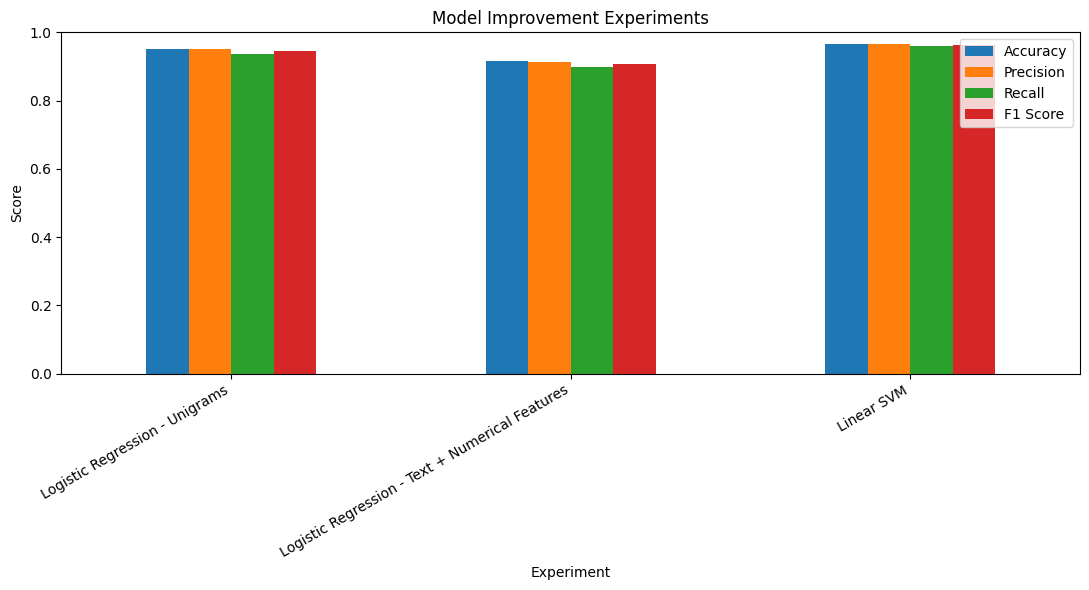

In [12]:
results = pd.DataFrame({
    "Experiment": [
        "Logistic Regression - Unigrams",
        "Logistic Regression - Text + Numerical Features",
        "Linear SVM"
    ],
    "Accuracy": [
        uni_accuracy,
        combined_accuracy,
        svm_accuracy
    ],
    "Precision": [
        uni_precision,
        combined_precision,
        svm_precision
    ],
    "Recall": [
        uni_recall,
        combined_recall,
        svm_recall
    ],
    "F1 Score": [
        uni_f1,
        combined_f1,
        svm_f1
    ]
})

display(results)

results.set_index("Experiment")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Improvement Experiments")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()